<font face="霞鹜文楷">

### 皮马印第安人糖尿病数据集朴素贝叶斯分类

#### 一、内容
1. 使用皮马印第安人糖尿病数据集进行分类任务;
2. 对比三种朴素贝叶斯算法的性能：
   - 伯努利朴素贝叶斯（BernoulliNB）
   - 高斯朴素贝叶斯（GaussianNB）
    - 多项式朴素贝叶斯（MultinomialNB）
3. 通过对数据进行适当的预处理，分别应用上述三种模型进行分类学习，计算分类精度等指标，并最终综合分析不同变体在生理特征数据上的表现差异。

#### 二、数据集介绍
皮马印第安人糖尿病数据集包含768个样本，8个特征变量和1个目标变量：
- Pregnancies: 怀孕次数
- Glucose: 葡萄糖浓度
- BloodPressure: 血压
- SkinThickness: 皮肤厚度
- Insulin: 胰岛素水平
- BMI: 身体质量指数
- DiabetesPedigreeFunction: 糖尿病家族史函数
- Age: 年龄
- Outcome: 目标变量（0=无糖尿病，1=有糖尿病）
</font>

In [2]:
# 导入所需库
# 数据处理与分析库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 机器学习模型库
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
# 预处理库
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 评估指标库
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示和图表样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

<font face="霞鹜文楷">

#### 三、数据加载与分析
加载数据集并查看前几行数据以了解特征结构。
</font>

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# 定义列名
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
# 加载数据
df = pd.read_csv(url, names=column_names)

# 显示数据基本信息
print(f"数据集形状: {df.shape}")
print(f"\n前5行数据:")
print(df.head())
print(f"总样本数: {df.shape[0]}")
print(f"特征数量: {df.shape[1] - 1}")  # 减去目标变量
print(f"\n数据类型:")
print(df.dtypes)

数据集形状: (768, 9)

前5行数据:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
总样本数: 768
特征数量: 8

数据类型:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Ag

缺失值统计:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

目标变量分布:
Outcome
0    500
1    268
Name: count, dtype: int64

类别比例:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


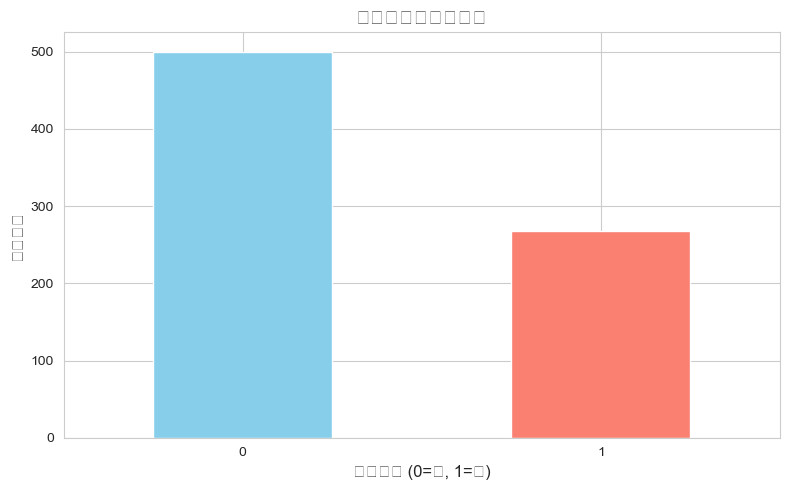

In [4]:
# 检查缺失值和数据分布
print(f"缺失值统计:")
print(df.isnull().sum())

# 检查目标变量分布
print(f"\n目标变量分布:")
print(df['Outcome'].value_counts())
print(f"\n类别比例:")
print(df['Outcome'].value_counts(normalize=True))

# [RUN] 可视化目标变量分布
plt.figure(figsize=(8, 5))
df['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('糖尿病患病情况分布', fontsize=14, fontweight='bold')
plt.xlabel('是否患病 (0=否, 1=是)', fontsize=12)
plt.ylabel('样本数量', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

##### 数据分析发现：
1. 数据集包含768个样本，无缺失值
2. 目标变量存在类别不平衡（约65%为阴性，35%为阳性）
3. 需要注意部分特征（如Glucose、BloodPressure等）存在0值，可能代表缺失
</font>

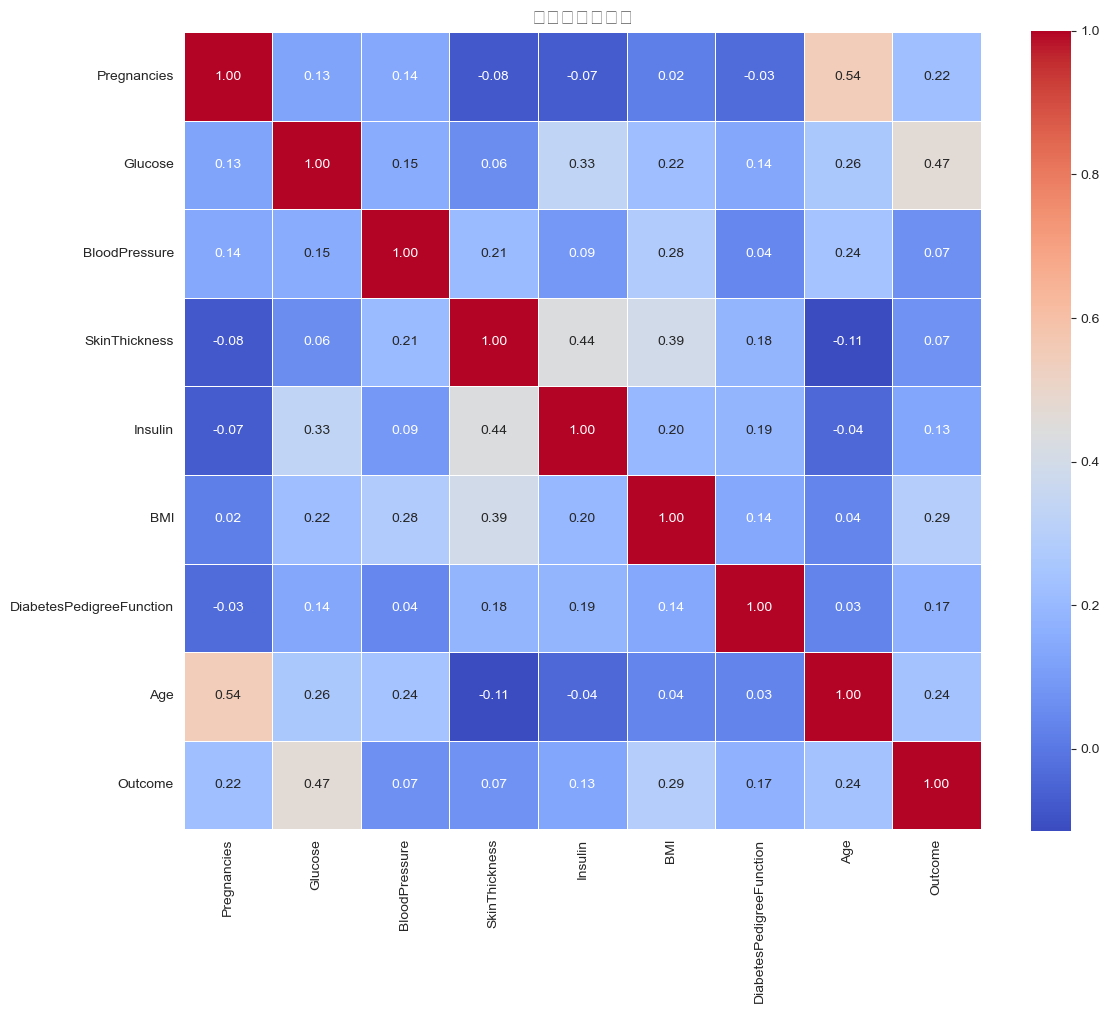


=== 特征与目标变量的相关性 ===
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [5]:
# 特征相关性分析
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('特征相关性热图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  输出与目标变量相关性最强的特征
print("\n=== 特征与目标变量的相关性 ===")
target_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(target_corr)

<font face="霞鹜文楷">

##### 相关性分析结果：
- Glucose（葡萄糖浓度）与糖尿病相关性最强
- BMI、Age、Pregnancies也显示出较强的正相关
- 这些特征对于预测糖尿病具有重要意义
</font>

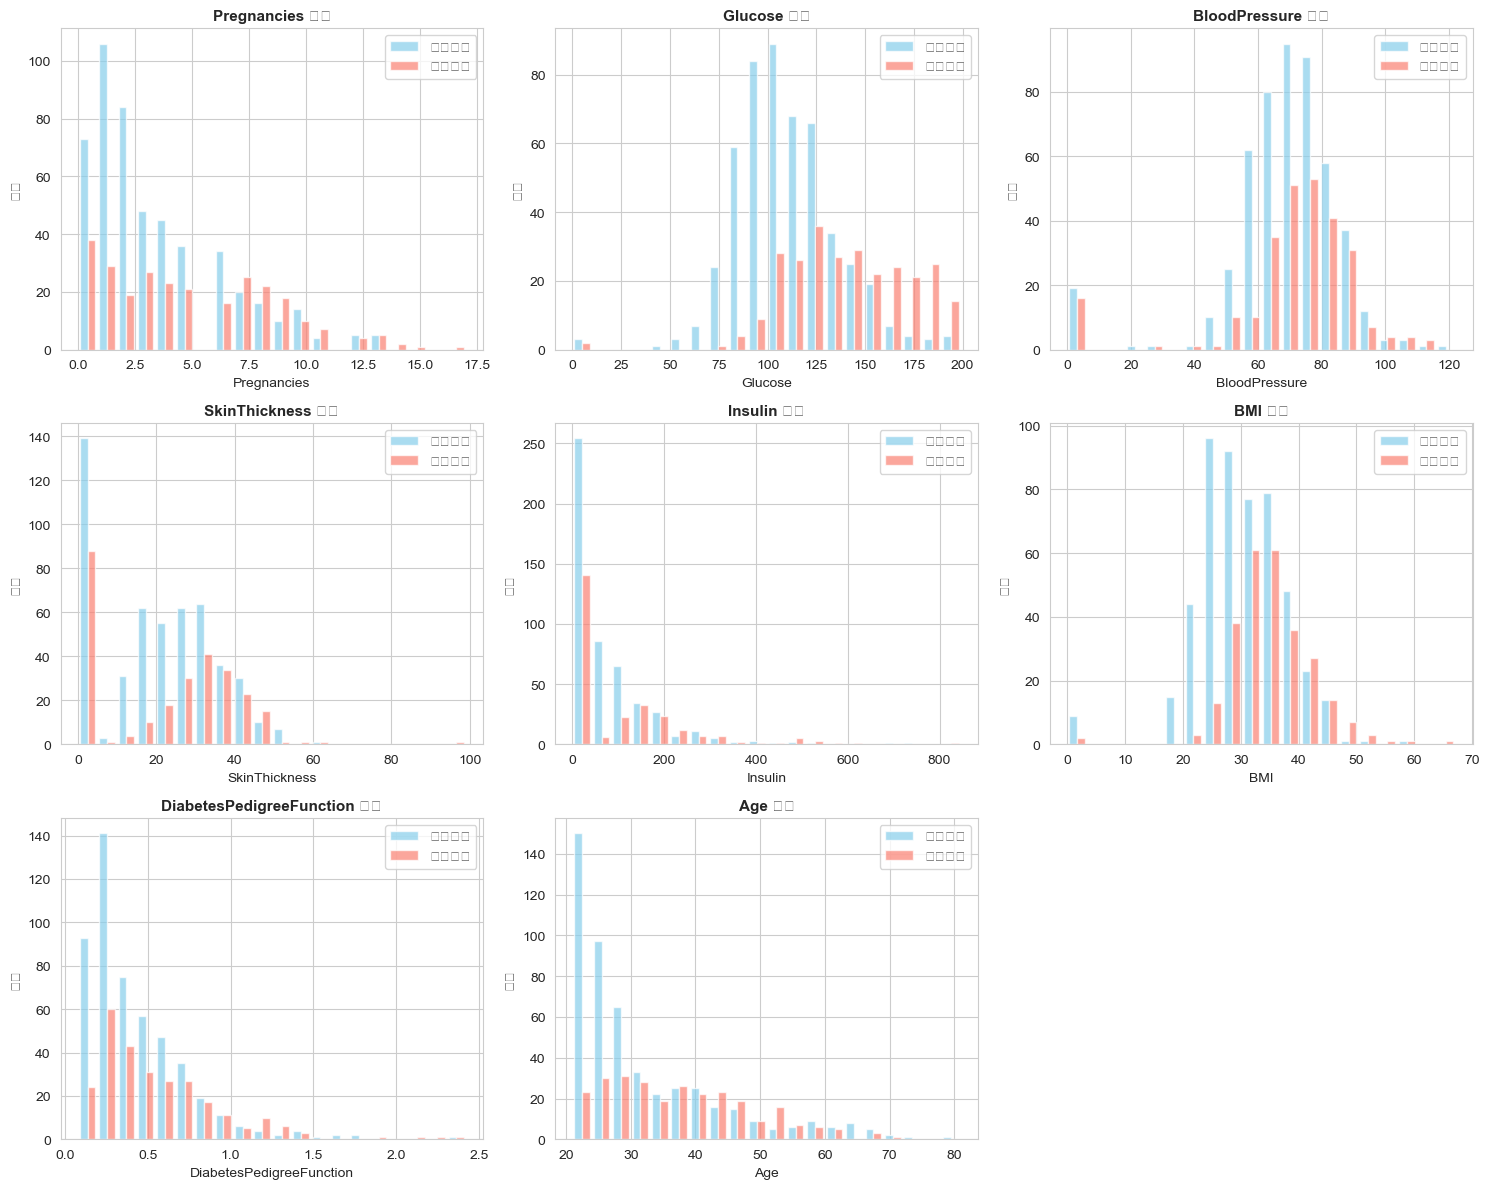

In [6]:
# 特征分布可视化
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns[:-1]):
    axes[idx].hist([df[df['Outcome']==0][col], df[df['Outcome']==1][col]], 
                   bins=20, label=['无糖尿病', '有糖尿病'], 
                   color=['skyblue', 'salmon'], alpha=0.7)
    axes[idx].set_title(f'{col} 分布', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('频数', fontsize=10)
    axes[idx].legend()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

#### 四、数据预处理
</font>

In [7]:
# 分离特征和目标变量
X = df.drop('Outcome', axis=1)  # 特征矩阵
y = df['Outcome']  # 特征矩阵

print("\n=== 数据集划分 ===")
print(f"特征矩阵形状: {X.shape}")
print(f"目标变量形状: {y.shape}")


=== 数据集划分 ===
特征矩阵形状: (768, 8)
目标变量形状: (768,)


In [8]:
# 划分训练集和测试集
# 使用stratify参数确保训练集和测试集中的类别比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"\n训练集类别分布:\n{y_train.value_counts()}")
print(f"\n测试集类别分布:\n{y_test.value_counts()}")


训练集大小: 614 样本
测试集大小: 154 样本

训练集类别分布:
Outcome
0    400
1    214
Name: count, dtype: int64

测试集类别分布:
Outcome
0    100
1     54
Name: count, dtype: int64


In [9]:
# 数据标准化处理
# 为不同的朴素贝叶斯算法准备不同的数据格式

# 1.高斯朴素贝叶斯：使用标准化数据
scaler_gaussian = StandardScaler()
X_train_gaussian = scaler_gaussian.fit_transform(X_train)
X_test_gaussian = scaler_gaussian.transform(X_test)

# 2.伯努利朴素贝叶斯：需要二值化数据（使用中位数阈值）
X_train_bernoulli = (X_train > X_train.median()).astype(int)
X_test_bernoulli = (X_test > X_train.median()).astype(int)

# 3.多项式朴素贝叶斯：需要非负数据，使用MinMax缩放到[0,1]再乘以100转为计数型
scaler_multinomial = MinMaxScaler()
X_train_multinomial = scaler_multinomial.fit_transform(X_train) * 100
X_test_multinomial = scaler_multinomial.transform(X_test) * 100

print("\n=== 数据预处理完成 ===")
print("1. 高斯朴素贝叶斯：标准化处理")
print("2. 伯努利朴素贝叶斯：二值化处理")
print("3. 多项式朴素贝叶斯：归一化后放大处理")



=== 数据预处理完成 ===
1. 高斯朴素贝叶斯：标准化处理
2. 伯努利朴素贝叶斯：二值化处理
3. 多项式朴素贝叶斯：归一化后放大处理


<font face="霞鹜文楷">

#### 五、模型训练与评估
</font>

In [10]:
# [CODE] 定义模型评估函数
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    完整的模型评估函数
    
    参数:
        model: 训练好的模型
        X_train, X_test: 训练集和测试集特征
        y_train, y_test: 训练集和测试集标签
        model_name: 模型名称
    
    返回:
        results: 包含各项评估指标的字典
    """
    # 训练集预测
    y_train_pred = model.predict(X_train)
    # 测试集预测
    y_test_pred = model.predict(X_test)
    
    # 计算各项指标
    results = {
        '模型名称': model_name,
        '训练集准确率': accuracy_score(y_train, y_train_pred),
        '测试集准确率': accuracy_score(y_test, y_test_pred),
        '精确率(Precision)': precision_score(y_test, y_test_pred),
        '召回率(Recall)': recall_score(y_test, y_test_pred),
        'F1分数': f1_score(y_test, y_test_pred),
        'AUC值': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }
    
    # 打印详细评估报告
    print(f"{model_name} - 模型评估报告")
    print(f"\n训练集准确率: {results['训练集准确率']:.4f}")
    print(f"测试集准确率: {results['测试集准确率']:.4f}")
    print(f"精确率: {results['精确率(Precision)']:.4f}")
    print(f"召回率: {results['召回率(Recall)']:.4f}")
    print(f"F1分数: {results['F1分数']:.4f}")
    print(f"AUC值: {results['AUC值']:.4f}")
    
    # 分类报告
    print(f"\n详细分类报告:")
    print(classification_report(y_test, y_test_pred, 
                                target_names=['无糖尿病', '有糖尿病']))
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_test_pred)
    
    return results, y_test_pred, cm

<font face="霞鹜文楷">

##### 5.1 高斯朴素贝叶斯（GaussianNB）

**算法原理：**
- 假设每个特征服从高斯（正态）分布
- 适用于连续型特征
- 通过计算每个类别下特征的均值和方差来建模
</font>

高斯朴素贝叶斯(GaussianNB) - 模型评估报告

训练集准确率: 0.7736
测试集准确率: 0.7078
精确率: 0.5738
召回率: 0.6481
F1分数: 0.6087
AUC值: 0.7728

详细分类报告:
              precision    recall  f1-score   support

        无糖尿病       0.80      0.74      0.77       100
        有糖尿病       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



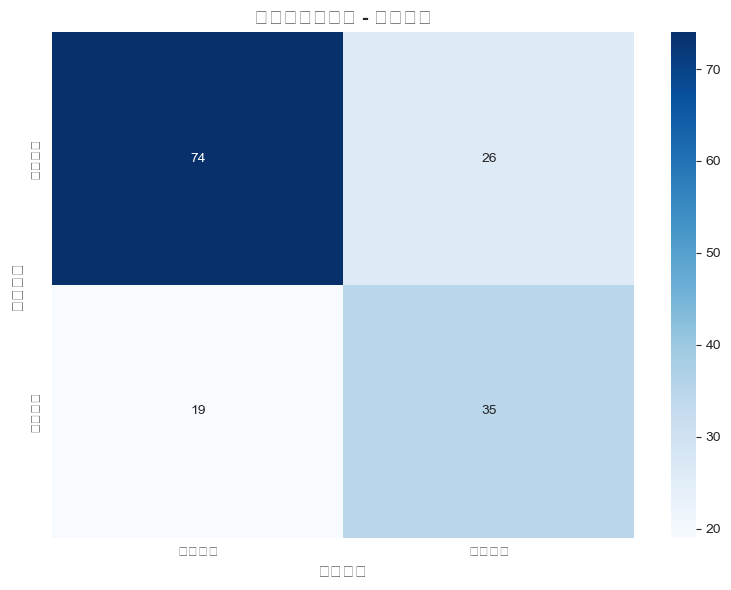

In [11]:
# 训练高斯朴素贝叶斯模型
# 创建并训练模型
gnb = GaussianNB()
gnb.fit(X_train_gaussian, y_train)

# 评估模型
results_gnb, y_pred_gnb, cm_gnb = evaluate_model(
    gnb, X_train_gaussian, X_test_gaussian, y_train, y_test, 
    "高斯朴素贝叶斯(GaussianNB)"
)

# 可视化高斯朴素贝叶斯的混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['无糖尿病', '有糖尿病'],
            yticklabels=['无糖尿病', '有糖尿病'])
plt.title('高斯朴素贝叶斯 - 混淆矩阵', fontsize=14, fontweight='bold')
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)
plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

##### 5.2 伯努利朴素贝叶斯（BernoulliNB）

**算法原理：**
- 假设特征服从伯努利分布（二值分布）
- 适用于二值特征或离散特征
- 每个特征只有两种状态（0或1）
</font>

伯努利朴素贝叶斯(BernoulliNB) - 模型评估报告

训练集准确率: 0.6971
测试集准确率: 0.7338
精确率: 0.6327
召回率: 0.5741
F1分数: 0.6019
AUC值: 0.7917

详细分类报告:
              precision    recall  f1-score   support

        无糖尿病       0.78      0.82      0.80       100
        有糖尿病       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



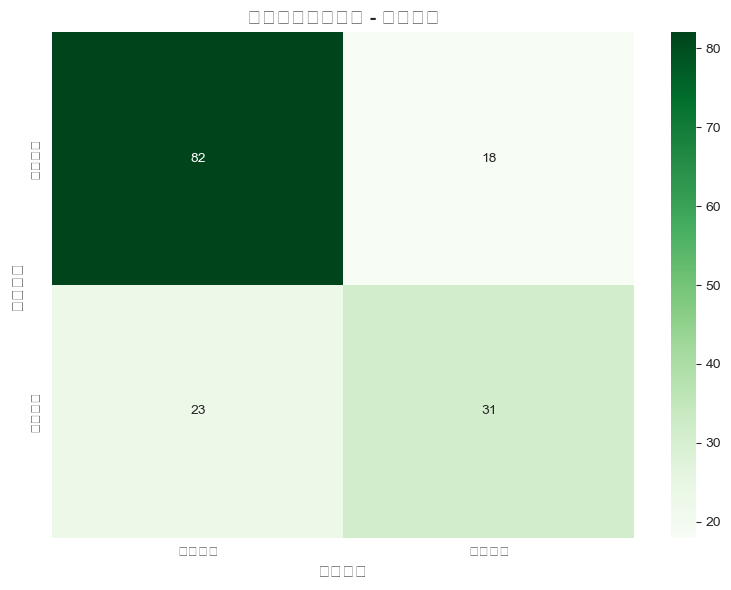

In [12]:
# 训练伯努利朴素贝叶斯模型
# 创建并训练模型
bnb = BernoulliNB()
bnb.fit(X_train_bernoulli, y_train)

# 评估模型
results_bnb, y_pred_bnb, cm_bnb = evaluate_model(
    bnb, X_train_bernoulli, X_test_bernoulli, y_train, y_test, 
    "伯努利朴素贝叶斯(BernoulliNB)"
)

# [RUN] 可视化伯努利朴素贝叶斯的混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['无糖尿病', '有糖尿病'],
            yticklabels=['无糖尿病', '有糖尿病'])
plt.title('伯努利朴素贝叶斯 - 混淆矩阵', fontsize=14, fontweight='bold')
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)
plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

##### 5.3 多项式朴素贝叶斯（MultinomialNB）

**算法原理：**
- 假设特征服从多项式分布
- 适用于离散计数特征（如词频统计）
- 要求特征值为非负整数或频率
</font>

多项式朴素贝叶斯(MultinomialNB) - 模型评估报告

训练集准确率: 0.6629
测试集准确率: 0.6104
精确率: 0.4583
召回率: 0.6111
F1分数: 0.5238
AUC值: 0.6765

详细分类报告:
              precision    recall  f1-score   support

        无糖尿病       0.74      0.61      0.67       100
        有糖尿病       0.46      0.61      0.52        54

    accuracy                           0.61       154
   macro avg       0.60      0.61      0.60       154
weighted avg       0.64      0.61      0.62       154



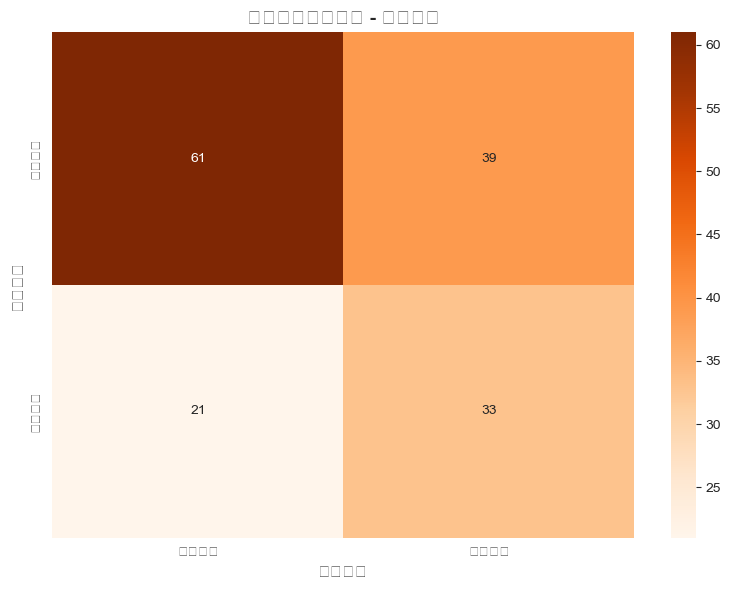

In [13]:
# 训练多项式朴素贝叶斯模型

# 创建并训练模型
mnb = MultinomialNB()
mnb.fit(X_train_multinomial, y_train)

# 评估模型
results_mnb, y_pred_mnb, cm_mnb = evaluate_model(
    mnb, X_train_multinomial, X_test_multinomial, y_train, y_test, 
    "多项式朴素贝叶斯(MultinomialNB)"
)

# [RUN] 可视化多项式朴素贝叶斯的混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['无糖尿病', '有糖尿病'],
            yticklabels=['无糖尿病', '有糖尿病'])
plt.title('多项式朴素贝叶斯 - 混淆矩阵', fontsize=14, fontweight='bold')
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)
plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

#### 六、模型对比分析
</font>


三种朴素贝叶斯算法性能对比
                         训练集准确率  测试集准确率  精确率(Precision)  召回率(Recall)    F1分数  \
模型名称                                                                           
高斯朴素贝叶斯(GaussianNB)      0.7736  0.7078          0.5738       0.6481  0.6087   
伯努利朴素贝叶斯(BernoulliNB)    0.6971  0.7338          0.6327       0.5741  0.6019   
多项式朴素贝叶斯(MultinomialNB)  0.6629  0.6104          0.4583       0.6111  0.5238   

                           AUC值  
模型名称                             
高斯朴素贝叶斯(GaussianNB)      0.7728  
伯努利朴素贝叶斯(BernoulliNB)    0.7917  
多项式朴素贝叶斯(MultinomialNB)  0.6765  


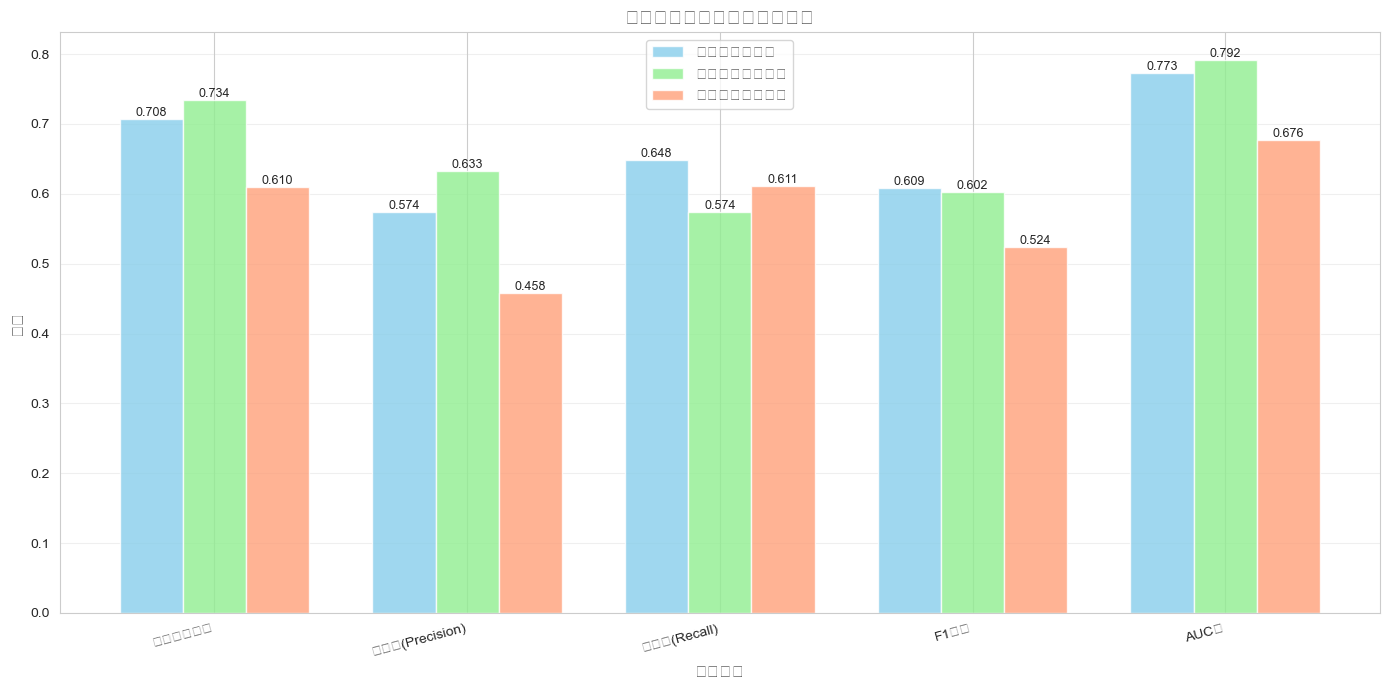

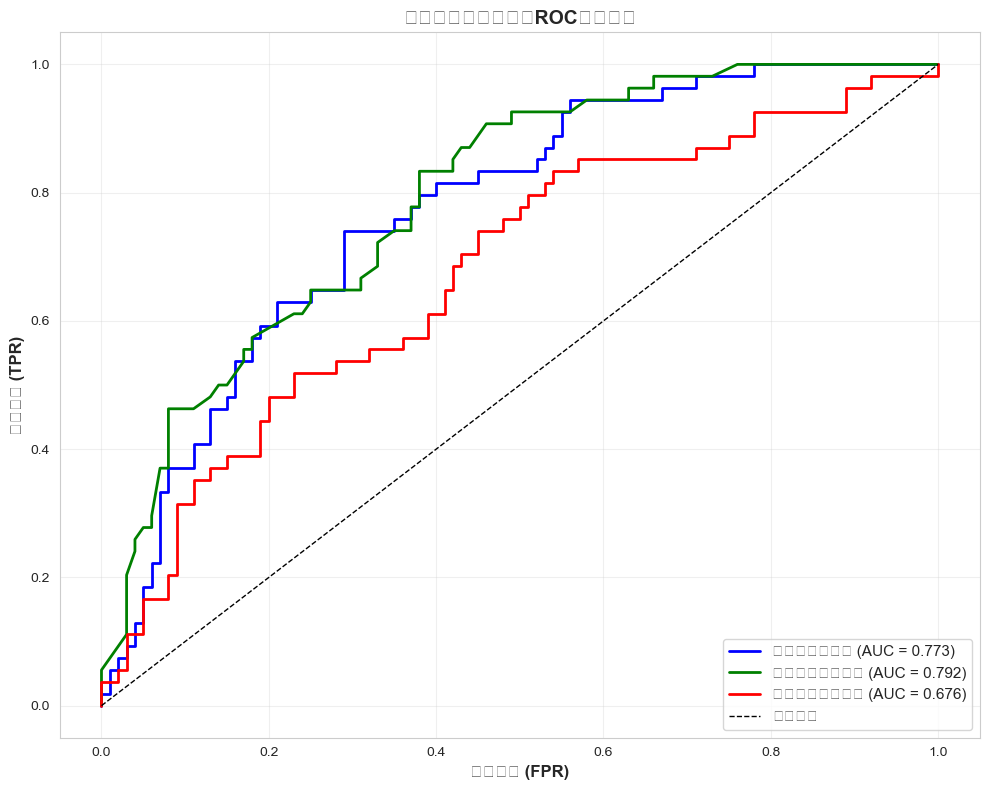

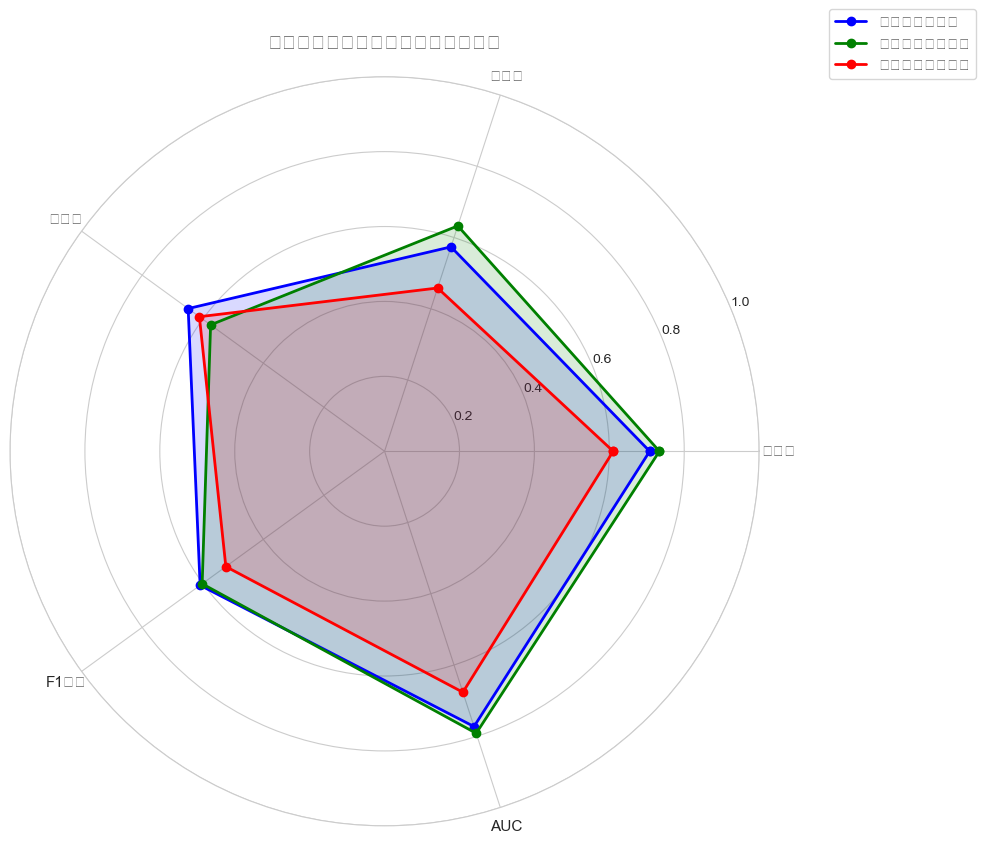

In [14]:
# [CODE] 汇总所有模型的性能指标
results_df = pd.DataFrame([results_gnb, results_bnb, results_mnb])
results_df = results_df.set_index('模型名称')

print("\n" + "="*80)
print("三种朴素贝叶斯算法性能对比")
print("="*80)
print(results_df.round(4))

# [RUN] 可视化性能对比 - 柱状图
metrics = ['测试集准确率', '精确率(Precision)', '召回率(Recall)', 'F1分数', 'AUC值']
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, results_df.iloc[0][metrics], width, 
               label='高斯朴素贝叶斯', color='skyblue', alpha=0.8)
bars2 = ax.bar(x, results_df.iloc[1][metrics], width, 
               label='伯努利朴素贝叶斯', color='lightgreen', alpha=0.8)
bars3 = ax.bar(x + width, results_df.iloc[2][metrics], width, 
               label='多项式朴素贝叶斯', color='lightsalmon', alpha=0.8)

ax.set_xlabel('评估指标', fontsize=12, fontweight='bold')
ax.set_ylabel('分数', fontsize=12, fontweight='bold')
ax.set_title('三种朴素贝叶斯算法性能对比', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 在柱状图上添加数值标签
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

plt.tight_layout()
plt.show()

# [RUN] ROC曲线对比
plt.figure(figsize=(10, 8))

# 计算每个模型的ROC曲线
# 高斯朴素贝叶斯
y_pred_proba_gnb = gnb.predict_proba(X_test_gaussian)[:, 1]
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_pred_proba_gnb)
auc_gnb = auc(fpr_gnb, tpr_gnb)

# 伯努利朴素贝叶斯
y_pred_proba_bnb = bnb.predict_proba(X_test_bernoulli)[:, 1]
fpr_bnb, tpr_bnb, _ = roc_curve(y_test, y_pred_proba_bnb)
auc_bnb = auc(fpr_bnb, tpr_bnb)

# 多项式朴素贝叶斯
y_pred_proba_mnb = mnb.predict_proba(X_test_multinomial)[:, 1]
fpr_mnb, tpr_mnb, _ = roc_curve(y_test, y_pred_proba_mnb)
auc_mnb = auc(fpr_mnb, tpr_mnb)

# 绘制ROC曲线
plt.plot(fpr_gnb, tpr_gnb, label=f'高斯朴素贝叶斯 (AUC = {auc_gnb:.3f})', 
         linewidth=2, color='blue')
plt.plot(fpr_bnb, tpr_bnb, label=f'伯努利朴素贝叶斯 (AUC = {auc_bnb:.3f})', 
         linewidth=2, color='green')
plt.plot(fpr_mnb, tpr_mnb, label=f'多项式朴素贝叶斯 (AUC = {auc_mnb:.3f})', 
         linewidth=2, color='red')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')

plt.xlabel('假阳性率 (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('真阳性率 (TPR)', fontsize=12, fontweight='bold')
plt.title('三种朴素贝叶斯算法ROC曲线对比', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# [RUN] 雷达图对比
from math import pi

categories = ['准确率', '精确率', '召回率', 'F1分数', 'AUC']
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

# 准备数据
values_gnb = [results_gnb['测试集准确率'], results_gnb['精确率(Precision)'], 
              results_gnb['召回率(Recall)'], results_gnb['F1分数'], results_gnb['AUC值']]
values_bnb = [results_bnb['测试集准确率'], results_bnb['精确率(Precision)'], 
              results_bnb['召回率(Recall)'], results_bnb['F1分数'], results_bnb['AUC值']]
values_mnb = [results_mnb['测试集准确率'], results_mnb['精确率(Precision)'], 
              results_mnb['召回率(Recall)'], results_mnb['F1分数'], results_mnb['AUC值']]

# 闭合图形
values_gnb += values_gnb[:1]
values_bnb += values_bnb[:1]
values_mnb += values_mnb[:1]

# 计算角度
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

# 绘制
ax.plot(angles, values_gnb, 'o-', linewidth=2, label='高斯朴素贝叶斯', color='blue')
ax.fill(angles, values_gnb, alpha=0.15, color='blue')

ax.plot(angles, values_bnb, 'o-', linewidth=2, label='伯努利朴素贝叶斯', color='green')
ax.fill(angles, values_bnb, alpha=0.15, color='green')

ax.plot(angles, values_mnb, 'o-', linewidth=2, label='多项式朴素贝叶斯', color='red')
ax.fill(angles, values_mnb, alpha=0.15, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title('三种朴素贝叶斯算法综合性能雷达图', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

## 七、实验结论与分析

### 7.1 模型性能总结

从实验结果来看，三种朴素贝叶斯算法在皮马印第安人糖尿病数据集上的表现各有特点：
</font>

In [15]:
# 输出详细分析报告
print("\n" + "="*80)
print("实验结论与详细分析")
print("="*80)

print("\n【1. 高斯朴素贝叶斯(GaussianNB)】")
print("-" * 60)
print(f"✓ 测试集准确率: {results_gnb['测试集准确率']:.4f}")
print(f"✓ AUC值: {results_gnb['AUC值']:.4f}")
print(f"✓ F1分数: {results_gnb['F1分数']:.4f}")
print("\n优势分析:")
print("  • 适合处理连续型特征，无需对原始数据进行过多转换")
print("  • 假设特征服从正态分布，在本数据集上表现较为稳定")
print("  • 模型训练速度快，计算效率高")
print("\n劣势分析:")
print("  • 强假设特征独立且服从高斯分布，可能不完全符合实际")
print("  • 对异常值较为敏感")

print("\n【2. 伯努利朴素贝叶斯(BernoulliNB)】")
print("-" * 60)
print(f"✓ 测试集准确率: {results_bnb['测试集准确率']:.4f}")
print(f"✓ AUC值: {results_bnb['AUC值']:.4f}")
print(f"✓ F1分数: {results_bnb['F1分数']:.4f}")
print("\n优势分析:")
print("  • 通过二值化处理简化了特征空间")
print("  • 对噪声有一定的鲁棒性")
print("  • 计算简单，适合大规模数据")
print("\n劣势分析:")
print("  • 二值化导致信息损失严重，丢失了特征的具体数值信息")
print("  • 性能通常低于其他两种方法")
print("  • 不适合本质上为连续型的医疗数据")

print("\n【3. 多项式朴素贝叶斯(MultinomialNB)】")
print("-" * 60)
print(f"✓ 测试集准确率: {results_mnb['测试集准确率']:.4f}")
print(f"✓ AUC值: {results_mnb['AUC值']:.4f}")
print(f"✓ F1分数: {results_mnb['F1分数']:.4f}")
print("\n优势分析:")
print("  • 适合处理计数型特征")
print("  • 通过归一化和缩放，保留了部分数值信息")
print("  • 在某些情况下可以取得不错的效果")
print("\n劣势分析:")
print("  • 需要非负特征，需要额外的数据预处理")
print("  • 假设特征为计数型，与医疗数据的实际分布可能存在偏差")



实验结论与详细分析

【1. 高斯朴素贝叶斯(GaussianNB)】
------------------------------------------------------------
✓ 测试集准确率: 0.7078
✓ AUC值: 0.7728
✓ F1分数: 0.6087

优势分析:
  • 适合处理连续型特征，无需对原始数据进行过多转换
  • 假设特征服从正态分布，在本数据集上表现较为稳定
  • 模型训练速度快，计算效率高

劣势分析:
  • 强假设特征独立且服从高斯分布，可能不完全符合实际
  • 对异常值较为敏感

【2. 伯努利朴素贝叶斯(BernoulliNB)】
------------------------------------------------------------
✓ 测试集准确率: 0.7338
✓ AUC值: 0.7917
✓ F1分数: 0.6019

优势分析:
  • 通过二值化处理简化了特征空间
  • 对噪声有一定的鲁棒性
  • 计算简单，适合大规模数据

劣势分析:
  • 二值化导致信息损失严重，丢失了特征的具体数值信息
  • 性能通常低于其他两种方法
  • 不适合本质上为连续型的医疗数据

【3. 多项式朴素贝叶斯(MultinomialNB)】
------------------------------------------------------------
✓ 测试集准确率: 0.6104
✓ AUC值: 0.6765
✓ F1分数: 0.5238

优势分析:
  • 适合处理计数型特征
  • 通过归一化和缩放，保留了部分数值信息
  • 在某些情况下可以取得不错的效果

劣势分析:
  • 需要非负特征，需要额外的数据预处理
  • 假设特征为计数型，与医疗数据的实际分布可能存在偏差
